## Analysis

### Load CSV

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Path configuration
BASE_DIR = './'
SUMMARY_PATH = os.path.join(BASE_DIR, "summary.csv")

In [24]:
if not os.path.exists(SUMMARY_PATH):
    raise FileNotFoundError("summary.csv not found.")

df = pd.read_csv(SUMMARY_PATH)

if df.empty:
    raise ValueError("summary.csv is empty.")

print("Loaded dataframe shape:", df.shape)
df.head()

Loaded dataframe shape: (7, 30)


,experiment_name,machine_name,request_throughput_avg,request_latency_avg_ms,request_latency_std_ms,time_to_first_token_avg_ms,time_to_first_token_std_ms,inter_token_latency_avg_ms,inter_token_latency_std_ms,time_to_second_token_avg_ms,...,ttst_ms_p90,ttst_ms_p99,inter_token_latency_ms_p50,inter_token_latency_ms_p90,inter_token_latency_ms_p99,input_sequence_length_avg,input_sequence_length_std,output_sequence_length_avg,output_sequence_length_std,avg_concurrency
0,N2_poti_PP_long_r1_780376,"poti[1,5]",0.056931,17561.504580,7.605487,397.261167,0.468119,33.888200,0.291482,33.458546,...,33.662829,33.726960,33.937505,34.155432,34.615519,1024.0,0.0,507.533333,4.400104,0.999788
1,N2_poti_TP_short_r1_780378,"poti[1,5]",0.241817,4133.885852,12.290393,555.136192,0.780071,28.186573,0.102223,28.177835,...,28.488397,29.108162,28.127366,28.330452,28.360484,128.0,0.0,127.966667,0.182574,0.999643
2,N2_poti_PP_short_r1_780413,"poti[1,3]",0.231840,4311.656248,2.844926,78.803583,0.256412,33.320868,0.051373,33.196647,...,33.329718,33.402316,33.326377,33.357196,33.380847,128.0,0.0,128.033333,0.182574,0.999613
3,N1_tupi_none_short_r1_780423,tupi6,0.471978,2117.053485,0.707969,25.959997,0.313330,16.478575,0.070244,16.331817,...,16.420658,16.480939,16.465979,16.473827,16.745563,128.0,0.0,127.900000,0.547723,0.999203
4,N2_poti_TP_long_r1_780377,"poti[1,5]",0.054236,18434.523031,51.408432,3861.769976,3.906470,28.783393,0.360213,28.279900,...,28.561795,28.696231,28.792462,29.037345,29.962845,1024.0,0.0,507.366667,6.445974,0.999823


### Analysis

In [25]:
experiment_name_mapping = {
    'N1_tupi_none_long_r1_780424': 'tupi (N1) Long Seq',
    'N1_tupi_none_short_r1_780423': 'tupi (N1) Short Seq (2)',
    'N2_poti_PP_long_r1_780376': 'poti (N2) PP Long Seq',
    'N2_poti_PP_short_r1_780413': 'poti (N2) PP Short Seq',
    'N2_poti_TP_short_r1_780378': 'poti (N2) TP Short Seq',
    'N2_poti_TP_long_r1_780377': 'poti (N2) TP Long Seq',
    'N1_tupi_none_short_r1_778989': 'tupi (N1) Short Seq (1)'
}

df['display_name'] = df['experiment_name'].map(experiment_name_mapping)

In [26]:
metrics_to_plot = [
    'request_throughput_avg',
    'request_latency_avg_ms',
    'time_to_first_token_avg_ms',
    'input_sequence_length_avg',
    'output_sequence_length_avg',
    'output_token_throughput_avg',
    'inter_token_latency_avg_ms',
]

In [27]:
# Identify communication experiments (PP / TP)
df['is_communication'] = df['display_name'].str.contains('PP|TP', case=False, na=False)

In [28]:
def format_experiment_name(name):
    """
    Example input:
    N2_poti_PP_long_r1_780376
    N1_tupi_none_short_r1_780423
    """

    parts = name.split('_')

    try:
        n_nodes = parts[0]            # N1 / N2
        system = parts[1]             # poti / tupi
        strategy = parts[2]           # none / PP / TP
        length = parts[3]             # short / long
    except IndexError:
        return name  # fallback

    # ===== CLEAN TERMS =====
    nodes = f"{n_nodes[1:]} node" if n_nodes == "N1" else f"{n_nodes[1:]} nodes"

    system = system.upper()

    if strategy == "none":
        strategy = "No Comm"
    elif strategy == "PP":
        strategy = "Pipeline Parallel"
    elif strategy == "TP":
        strategy = "Tensor Parallel"

    length = "Short Input" if length == "short" else "Long Input"

    # ===== FINAL LABEL =====
    return f"{nodes} {system}\n{strategy} {length}"

In [29]:
def get_ylabel(metric_name):
    name = metric_name.lower()

    if 'latency' in name:
        return 'Latency (ms)'
    elif 'throughput' in name:
        return 'Throughput (tokens/s)'
    elif 'tokens_per_second' in name:
        return 'Throughput (tokens/s)'
    elif 'time' in name:
        return 'Time (ms)'
    elif 'ttft' in name:
        return 'Time to First Token (ms)'
    else:
        return 'Value'

In [30]:
def pretty_metric_name(metric_name):
    return (
        metric_name
        .replace('_avg_ms', '')
        .replace('_avg', '')
        .replace('_', ' ')
        .title()
    )

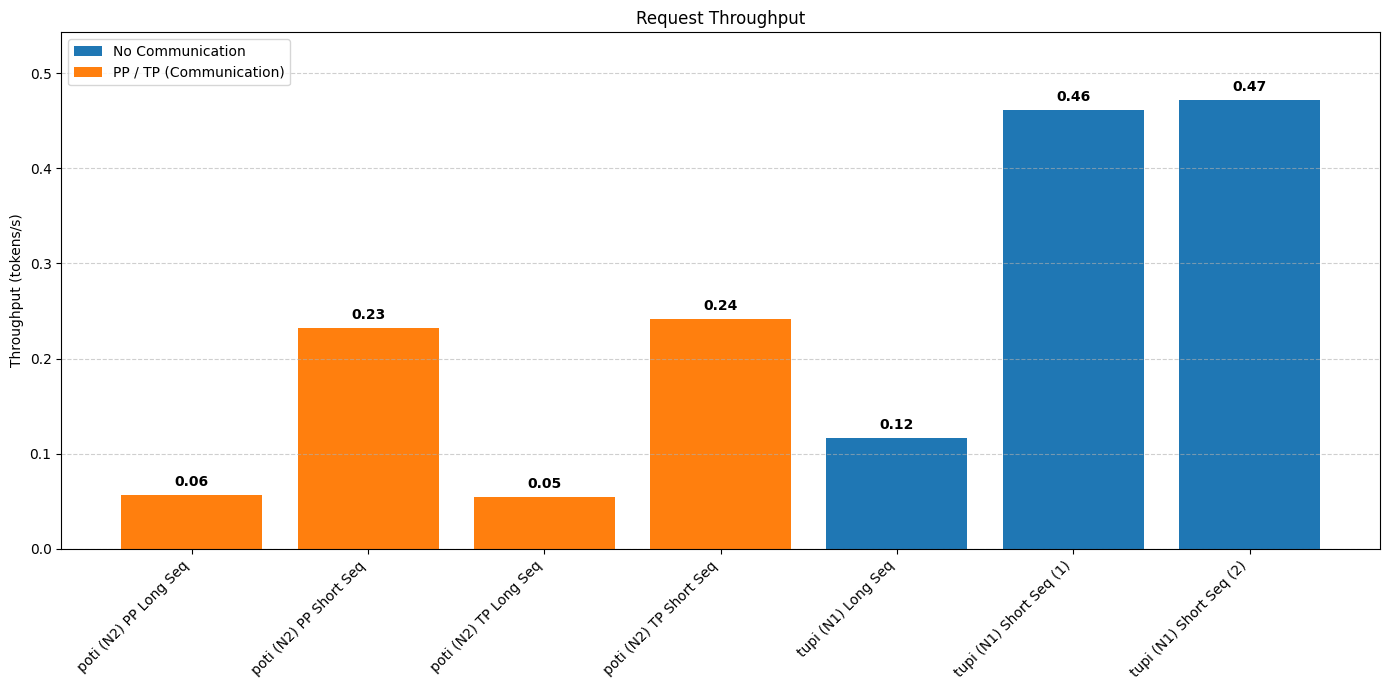

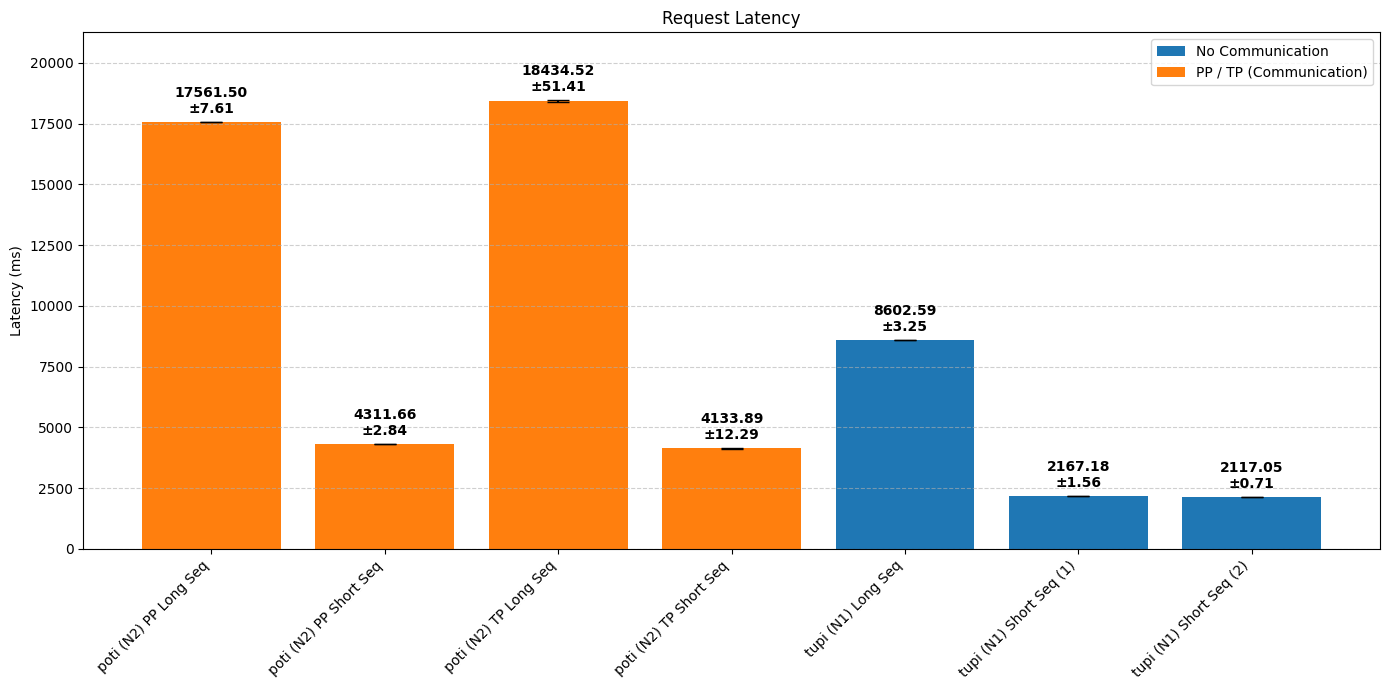

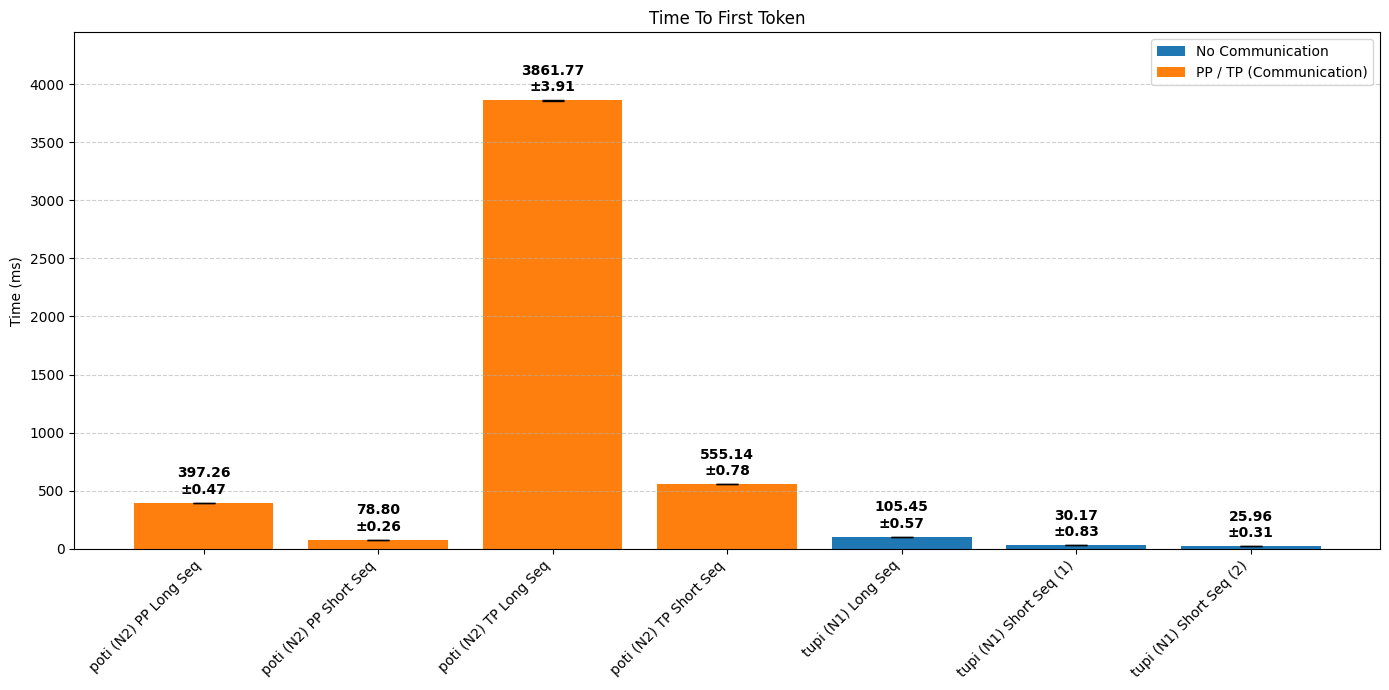

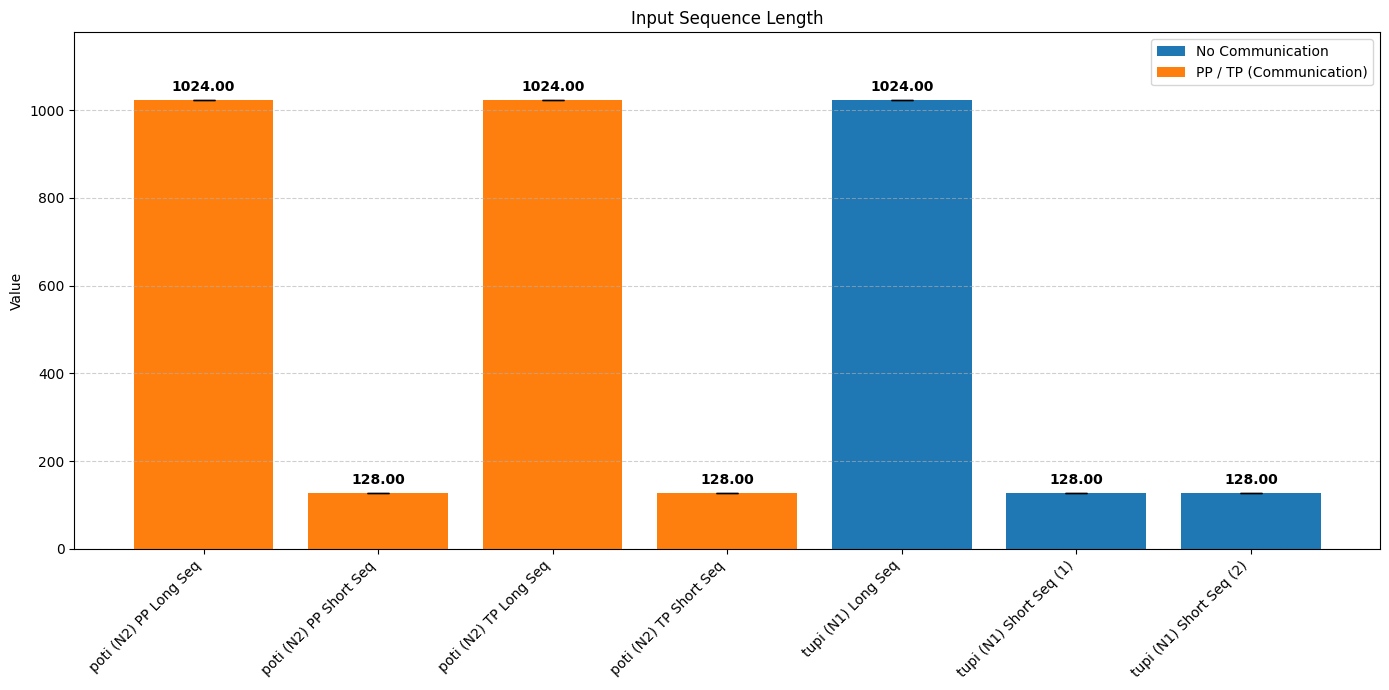

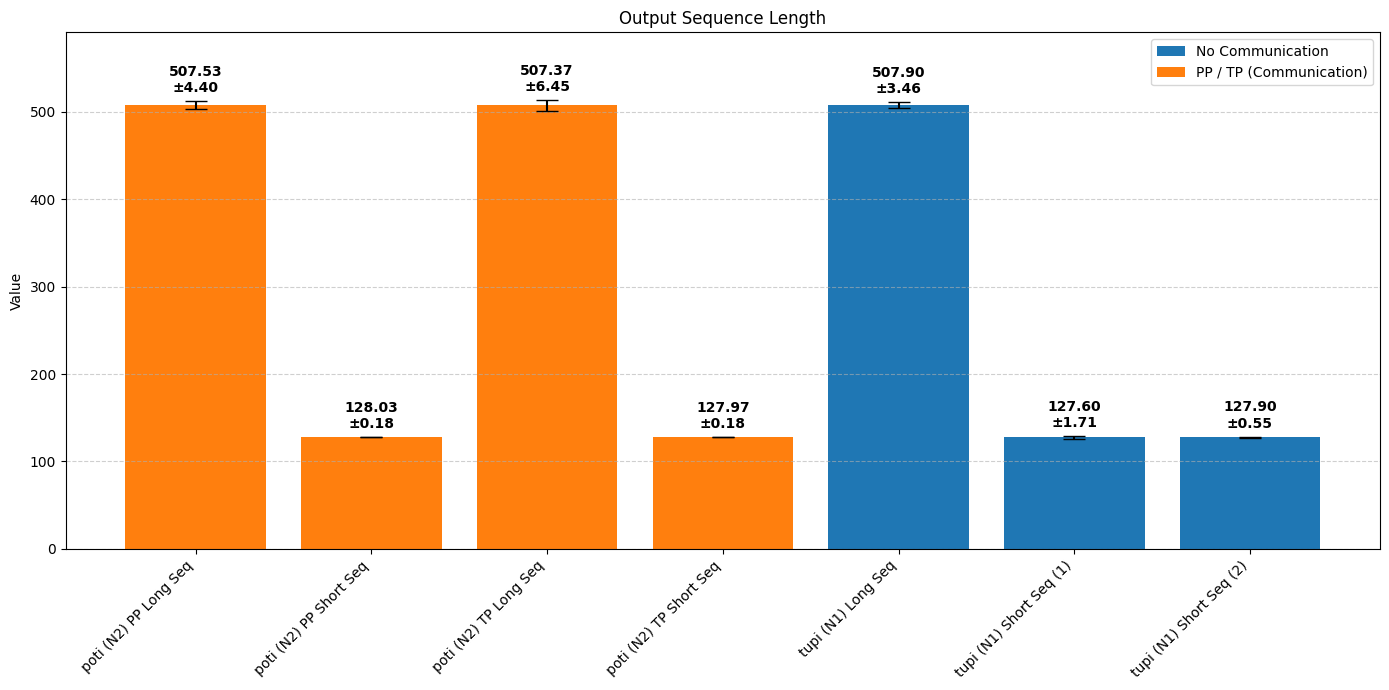

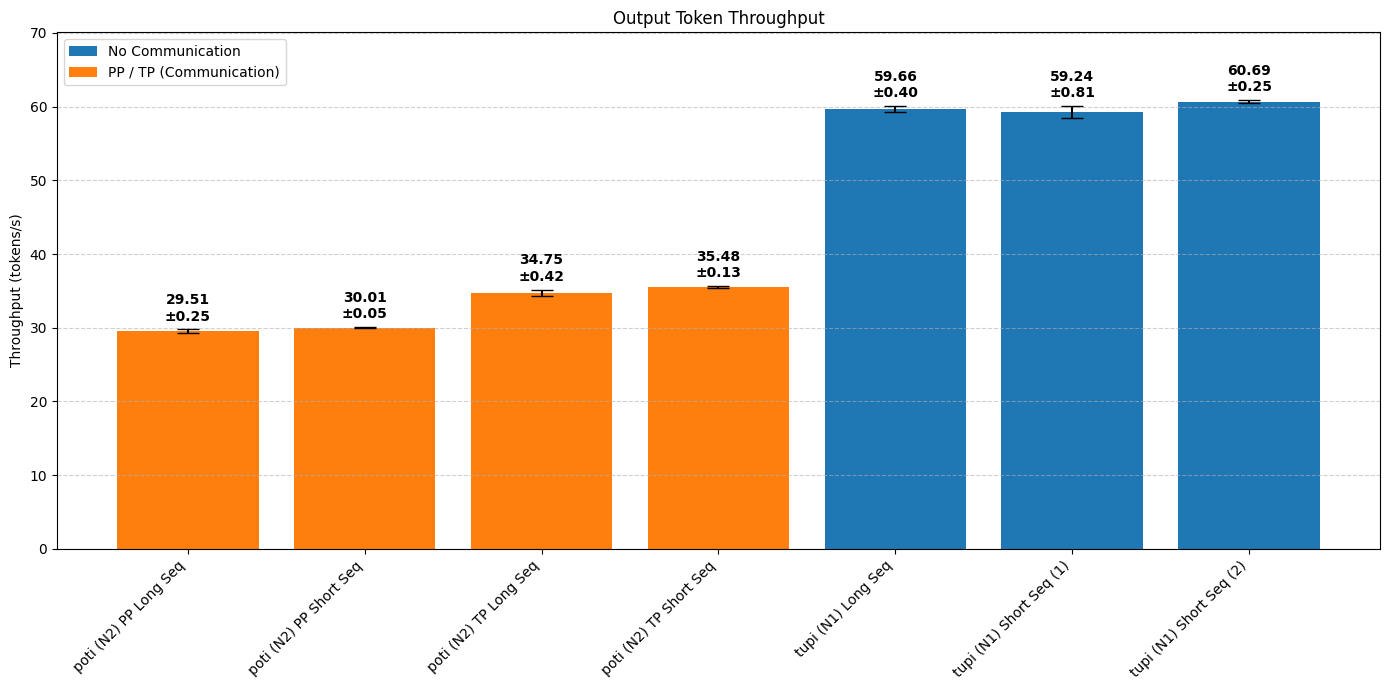

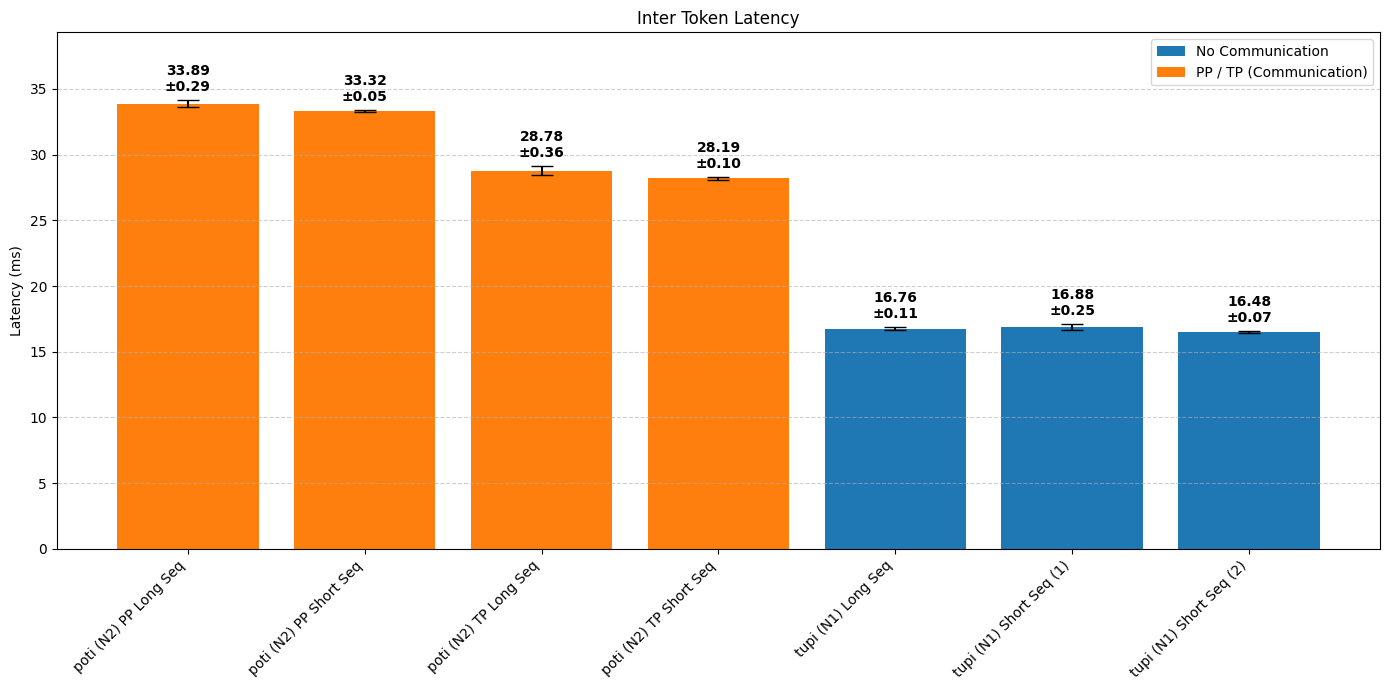

In [31]:
for avg_col in metrics_to_plot:

    # Handle std naming properly
    if avg_col.endswith('_avg_ms'):
        std_col = avg_col.replace('_avg_ms', '_std_ms')
    else:
        std_col = avg_col.replace('_avg', '_std')

    if avg_col not in df.columns:
        print(f"Skipping {avg_col}: column not found.")
        continue

    plot_df = df[['display_name', 'machine_name', 'is_communication', avg_col]].copy()

    if std_col in df.columns:
        plot_df[std_col] = df[std_col]

    plot_df = plot_df.dropna(subset=[avg_col])

    if plot_df.empty:
        continue

    plot_df = plot_df.sort_values('display_name').reset_index(drop=True)

    x = np.arange(len(plot_df))
    y = plot_df[avg_col].values

    has_std = std_col in plot_df.columns and plot_df[std_col].notna().any()
    yerr = plot_df[std_col].values if has_std else None 

    # ===== COLOR LOGIC =====
    colors = [
        'tab:blue' if not is_comm else 'tab:orange'
        for is_comm in plot_df['is_communication']
    ]

    plt.figure(figsize=(14, 7))

    bars = plt.bar(
        x,
        y,
        yerr=yerr,
        capsize=8 if has_std else 0,
        color=colors
    )

    # ===== LABELS =====
    offset = 0.02 * np.nanmax(y)

    max_height = 0  # track highest point (including std)

    for i, (xi, yi) in enumerate(zip(x, y)):
        label = f"{yi:.2f}"

        if has_std:
            std_val = yerr[i]
            if not np.isnan(std_val) and std_val > 0:
                label += f"\n±{std_val:.2f}"
                y_pos = yi + std_val + offset
                max_height = max(max_height, yi + std_val)
            else:
                y_pos = yi + offset
                max_height = max(max_height, yi)
        else:
            y_pos = yi + offset
            max_height = max(max_height, yi)

        plt.text(
            xi,
            y_pos,
            label,
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    # ===== ADD HEADROOM =====
    plt.ylim(0, max_height * 1.15)  # 15% extra space

    plot_df['pretty_name'] = plot_df['display_name'].apply(format_experiment_name)

    # ===== X LABELS =====
    labels = plot_df['pretty_name']

    plt.xticks(x, labels, rotation=45, ha='right')

    # ===== LEGEND =====
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='tab:blue', label='No Communication'),
        Patch(facecolor='tab:orange', label='PP / TP (Communication)')
    ]
    plt.legend(handles=legend_elements)

    # ===== FINAL ====
    plt.title(pretty_metric_name(avg_col))
    plt.ylabel(get_ylabel(avg_col))    
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

Focusing strictly on the time metrics, the results show a more nuanced trade-off between computation and communication that depends on the inference phase. The single-machine configuration achieves the lowest overall request latency and inter-token latency, as all computation is local and no synchronization or data transfer is required. When tensor parallelism is introduced, latency increases due to frequent inter-GPU communication at every layer, but this overhead remains relatively controlled because computation is still performed concurrently across devices, leading to good inter-token latency during the decode phase.

Pipeline parallelism, however, exhibits contrasting behavior between phases. During prefill, it can achieve significantly lower time to first token (TTFT), especially for long inputs, because different pipeline stages process multiple tokens concurrently once the pipeline is filled. This allows the workload to be effectively distributed across GPUs, reducing the initial response time. In contrast, during the decode phase, where tokens are generated sequentially, pipeline parallelism becomes less efficient. Each token must traverse all stages in order, introducing synchronization delays and idle periods (pipeline bubbles), which increases inter-token latency. As a result, while pipeline parallelism can outperform tensor parallelism in TTFT, it tends to have worse per-token latency and, in many cases, higher overall request latency due to these sequential dependencies.